# Interest rates and mortgages 2020
This is exercise 50, Chapter 7 Intro Stats

### A plot of mortgages in the United States (in trillions of dollars) vs. the interest rate at various times over the past 25 years.

In [34]:
import pandas as pd

df = pd.read_csv("../../data/interest_rates_and_mortgages_2020.txt", sep="\t")

df.head()

,Year,Interest.rate,Mortgages($T)
0,1985,12.43,2.415332
1,1986,10.19,2.655580
2,1987,10.21,2.956686
3,1988,10.34,3.274089
4,1989,10.32,3.526605


In [35]:
r = df.corr()["Interest.rate"]["Mortgages($T)"]
print(r)

-0.8671000169717612


The correleation is -0.867

In [36]:
mean_mortgage = df["Mortgages($T)"].mean()
mean_interest_rate = df["Interest.rate"].mean()
print(f"mean_mortgage = ${mean_mortgage:.3f} T")
print(f"mean_interest_rate = {mean_interest_rate:.3f} %")

mean_mortgage = $8.846 T
mean_interest_rate = 6.642 %


$$
\mu_{mortgage} = 8.846 \\
\mu_{interest rate} = 6.642 
$$

In [42]:
s_mortgage = df['Mortgages($T)'].std()
s_interest_rate = df['Interest.rate'].std()
print(f's_mortgage = ${s_mortgage:.3f}T')
print(f's_interest_rate = {s_interest_rate:.2f}%')

s_mortgage = $4.794T
s_interest_rate = 2.24%


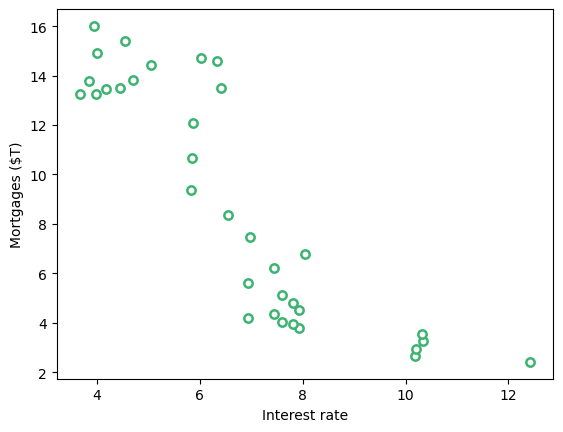

In [38]:
import matplotlib.pyplot as plt

plt.scatter(df["Interest.rate"], df["Mortgages($T)"], alpha=1, edgecolors="mediumseagreen", linewidths=1.8, color="w")
plt.xlabel("Interest rate")
plt.ylabel("Mortgages ($T)")
plt.show()

a) Is a regression model appropriate for predicting mortgage amount from interest rates? Explain.
No. The scatter looks like a curve.
I will try to re-express in a log format

In [67]:
import numpy as np
log_mortgage = np.log(df["Mortgages($T)"])

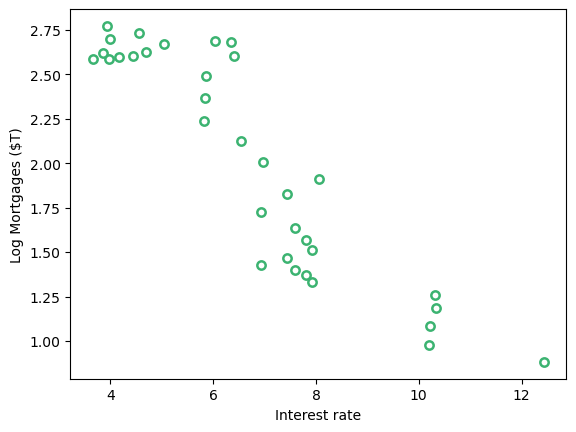

In [68]:
plt.scatter(df["Interest.rate"], log_mortgage, alpha=1, edgecolors="mediumseagreen", linewidths=1.8, color="w")
plt.xlabel("Interest rate")
plt.ylabel("Log Mortgages ($T)")
plt.show()

b) Regardless of your answer to part a, find the equation that predicts mortgage amount from interest rates.
Ok, well i'll do it for both regular and log:
#### Regular Mortgage
$\beta_1 = -0.867 \cdot (\frac{4.794}{2.24}) = -1.8555$ 

$\beta_0 = 8.846 - (-1.8555) \cdot 6.642 = 21.175$ 

$\hat{mortgage} = 21.175 - 1.8555x$


In [62]:
mortgage_b1 = r * (s_mortgage/s_interest_rate)
print(f"mortgage_b1: {mortgage_b1:.4f}")
mortgage_b0 = mean_mortgage - (mortgage_b1 * mean_interest_rate)
print(f"mortgage_b0: {mortgage_b0:.4f}")
def mortgage_predictor(x):
    return mortgage_b0 + mortgage_b1 * x

mortgage_pred = mortgage_predictor(df["Interest.rate"])

# Just checking i got it right
from scipy.stats import linregress
slope = linregress(df["Interest.rate"], df["Mortgages($T)"]).slope
# assert abs(mortgage_b1 - slope) < 0.001
print(f"slope: {slope}")

mortgage_b1: -1.8562
mortgage_b0: 21.1745
slope: nan


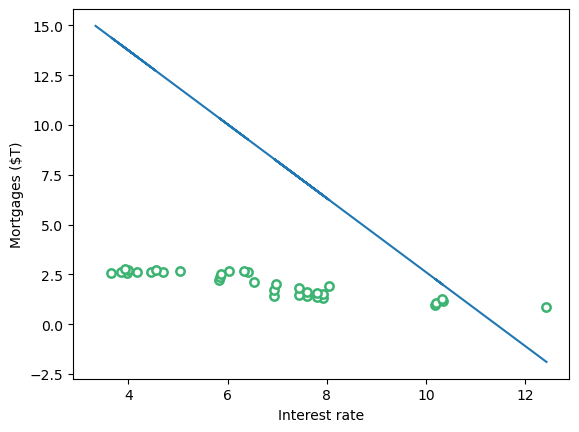

In [65]:
plt.scatter(df["Interest.rate"], log_mortgage_total, alpha=1, edgecolors="mediumseagreen", linewidths=1.8, color="w")
plt.plot(df["Interest.rate"], mortgage_pred)
plt.xlabel("Interest rate")
plt.ylabel("Mortgages ($T)")
plt.show()

Doesnt look great does it!

lets try log mortgage:
#### Log Mortgage

In [ ]:
log_mortgage_mean = log_mortgage.mean()
log_mortgage_std = log_mortgage.std()

log_mortgage_b1 = r * (log_mortgage_std/s_interest_rate)
log_mortgage_b0 = log_mortgage_mean - log_mortgage_b1 * mean_interest_rate

def log_mortgage_predictor(interest_rate):
    return log_mortgage_b0 + log_mortgage_b1 * interest_rate

log_mortgage_predicted = log_mortgage_predictor(df["Interest.rate"])
print(log_mortgage_predicted.head())

0    0.608981
1    1.150290
2    1.145457
3    1.114042
4    1.118875
Name: Interest.rate, dtype: float64


Lets test it on a graph!

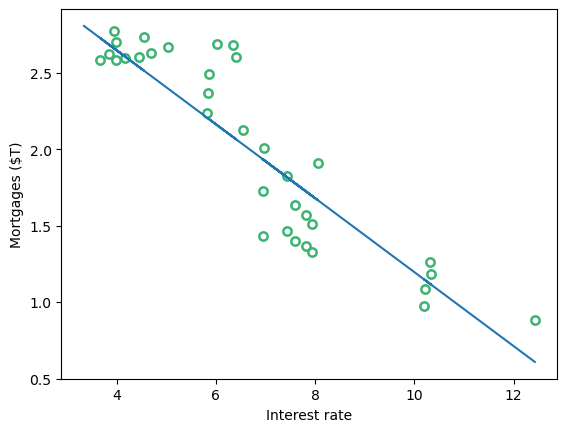

In [82]:
plt.scatter(df["Interest.rate"], log_mortgage_total, alpha=1, edgecolors="mediumseagreen", linewidths=1.8, color="w")
plt.plot(df["Interest.rate"], log_mortgage_predicted)
plt.xlabel("Interest rate")
plt.ylabel("Mortgages ($T)")
plt.show()

Much better! 🎉

##### c) What would you predict the mortgage amount would be if the interest rates climbed to 13%?
I'll use both regression functions shall I?

In [83]:
print(f"{mortgage_predictor(13):.0f}")

-3


The regular (non-log) model predicted a mortgage of -3, which doesn't make sense.

In [85]:
print(f"{log_mortgage_predictor(13):.0f}")

0


The Log predictor predicted mortgage of 0

#### d) Do you have any reservations about your prediction in part c? Explain.


Yes, a mortgage of -3 at 13% does not seem likely. 